# 0. Setup Python

In [455]:
#First of all, let's import all the necessary libraries and check the versions to ensure compatibility.
#We will follow what what recommended by the professor 
# i used those command in the terminal to set up the environment for this project :
#python -m pip install --upgrade pip
#python -m pip install uv
# uv init
# then uv add scikit-learn numpy pandas matplotlib packaging ipykernel
#to create a .venv folder and the pyproject.toml file

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 12)

# Scikit-Learn ≥1.8.0 is required
import sklearn
assert sklearn.__version__ >= "1.8.0"
print(sklearn.__version__)

# Common imports
import numpy as np
import pandas as pd
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

1.8.0


# 1. Look at the Big Picture

What do we want to achieve ?

We want to predict the ratio of people attending a lesson. We will base our research on the data of an backup and also during the examen, try to predict one ratio, based on data given in the *lessen-groep.csv*

This a problem of supervised learning:  our label will be "aanwezigheidsgraad", which is the ratio between userCount/totalStudents which

This is then a Regression Problem because we want to predict a numerical value.


# 2. Extract Data

Now, we will import the data from the database in order to analyse the data.

They were stored in a backup and were opened with SQL SERVER 2022.

Here is the query SQL i used tro fetch the data :

-- SELECT 
-- f.DateKey AS [date], 

-- f.FromTimeKey AS [from], 

-- f.UntilTimeKey AS [until], 

-- a.CanonicalActivity AS activity,

-- s.SubgroupCode AS subgroup, 

-- s.ProgramName AS program, 

-- r.RoomFloor AS [floor], 

-- r.Category AS roomcategory, 

-- r.Capacity AS capacity, 

-- r.Area AS area, 

-- c.ClassCredits AS credits,

-- f.UserCount as usercount,
    
-- f.TotalStudents as totalstudents

-- FROM 
--     dbo.FactLecture f

-- INNER JOIN 
--     dbo.DimActivity a ON f.ActivityKey = a.ActivityKey

-- INNER JOIN 
--     dbo.DimSubgroup s ON f.SubgroupKey = s.SubgroupKey

-- INNER JOIN 
--     dbo.DimRoom r ON f.RoomKey = r.RoomKey
    
-- INNER JOIN 
--     dbo.DimClass c ON f.ClassKey = c.ClassKey;

In [456]:


csv_path = 'aanwezigheden_project.csv'

df = pd.read_csv(csv_path, sep=None, engine='python')
df.head(10)





,﻿date,from,until,activity,subgroup,program,floor,roomcategory,capacity,area,credits,usercount,totalstudents
0,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,5.0,20
1,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,7.0,17
2,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,4.0,21
3,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,2.0,21
4,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,1.0,21
5,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,8.0,20
6,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,7.0,17
7,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,5.0,21
8,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,7.0,21
9,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,2.0,21


In [457]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18499 entries, 0 to 18498
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ﻿date          18499 non-null  int64  
 1   from           18499 non-null  int64  
 2   until          18499 non-null  int64  
 3   activity       18499 non-null  str    
 4   subgroup       18499 non-null  str    
 5   program        18499 non-null  str    
 6   floor          18499 non-null  int64  
 7   roomcategory   18499 non-null  str    
 8   capacity       18499 non-null  int64  
 9   area           18499 non-null  float64
 10  credits        18499 non-null  int64  
 11  usercount      6977 non-null   float64
 12  totalstudents  18499 non-null  int64  
dtypes: float64(2), int64(7), str(4)
memory usage: 1.8 MB


We have 6977 record for usercount different from NULL.
Thus i took the decision to remove all the record where usercount are NULL, as userCount is the base to have the target to be predicted.

After, we will create our target to see what are the feature and attribute to keep in our model later on the section 4.

In [458]:
#drop all the rows where 'usercount' is 0, otherwise, we will have a lot of rows with 0 students present, 
# which will skew our analysis and model training.
df = df.dropna(subset=['usercount'])

#creating our target variable 'aanwezigheidsgraad' by dividing the number of students present ('usercount') 
# by the total number of students ('totalstudents')
df['aanwezigheidsgraad'] = df['usercount'] / df['totalstudents']

#to protect data leakage !
df = df.drop(columns=['usercount', 'totalstudents'])

df.head(10)

,﻿date,from,until,activity,subgroup,program,floor,roomcategory,capacity,area,credits,aanwezigheidsgraad
0,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.250000
1,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.411765
2,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.190476
3,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.095238
4,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.047619
5,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.400000
6,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.411765
7,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.238095
8,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.333333
9,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.095238


In [459]:
df.info()

<class 'pandas.DataFrame'>
Index: 6977 entries, 0 to 18493
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ﻿date               6977 non-null   int64  
 1   from                6977 non-null   int64  
 2   until               6977 non-null   int64  
 3   activity            6977 non-null   str    
 4   subgroup            6977 non-null   str    
 5   program             6977 non-null   str    
 6   floor               6977 non-null   int64  
 7   roomcategory        6977 non-null   str    
 8   capacity            6977 non-null   int64  
 9   area                6977 non-null   float64
 10  credits             6977 non-null   int64  
 11  aanwezigheidsgraad  6977 non-null   float64
dtypes: float64(2), int64(6), str(4)
memory usage: 708.6 KB


# Create a test & training set

From now, we should ONLY work on our train set.

In [460]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [461]:
len(train_set)

5581

In [462]:
len(test_set)

1396

In [463]:
len(train_set) + len(test_set)

6977

In [464]:
df = train_set.copy()

# 3. Discover and Visualize the Data to Gain Insights

We will first take a look to what does the data look  like to gain insight and to prepare our data cleaning and feature engineering.

<Axes: >

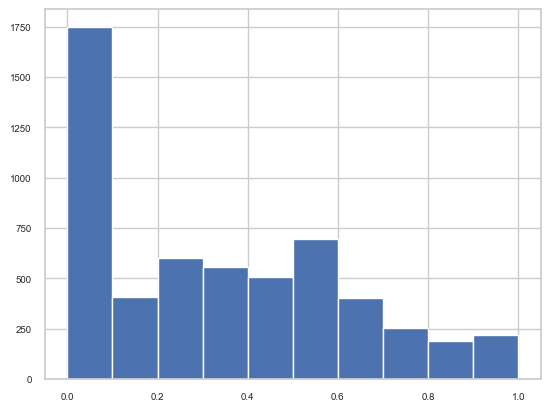

In [465]:
df["aanwezigheidsgraad"].hist()

Let's start with creating some new feature before to explore deeper the data.
We will later, if relevant, perform those transformation with sci kit learn in the section 4.

date column drop and extraction of month and day of week

calculate the duration of a course and drop from & until

calculate the is morning feature to discriminate between before 12 am and after


In [466]:
#make sure we do not have unwanted characters in the column names and remove any leading or trailing whitespace
df.columns = df.columns.str.replace('\ufeff', '').str.strip()

#feature engineering : extracting date features from the 'date' column
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
#feature engineering : extracting month and day of the week from the 'date' column
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek  # 0 = Maandag, 1 = Dinsdag, ..., 6 = Zondag

df.drop("date", axis=1, inplace=True)
#feature engineering : calculating the duration of each session in hours

#because in lessen groepen we had values without second and in the SQL extract, we had values with seconds, we need to convert those values to a consistent format before calculating the duration
df['until'] = np.where(df['until'] > 9999, df['until'] // 100, df['until'])
df['from'] = np.where(df['from'] > 9999, df['from'] // 100, df['from'])

from_decimal = (df['from'] // 100) + ((df['from'] % 100) / 60)
until_decimal = (df['until'] // 100) + ((df['until'] % 100) / 60)
df['duration_hours'] = (until_decimal - from_decimal) 

df['is_morning'] = (df['from'] < 1200).astype(int)

df.drop("from", axis=1, inplace=True)
df.drop("until", axis=1, inplace=True)



df.head(10)

,activity,subgroup,program,floor,roomcategory,capacity,area,credits,aanwezigheidsgraad,month,day_of_week,duration_hours,is_morning
17410,Activerend hoorcollege,PBA-BM-SCM/VT/KM,PBA-BM-SCM,2,auditorium,101,125.08,4,1.000000,10,1,3.25,1
16061,Activerend hoorcollege,PGD-SAL/1,PGD-SAL,1,leslokaal,26,58.05,6,0.142857,10,0,2.00,0
1010,Oefensessie,PBA-VG-VG/2F1,PBA-VG-VG,1,leslokaal,26,58.05,3,0.400000,12,1,2.00,1
3795,Activerend hoorcollege,PBA-TIN-TI/2A2,PBA-TIN-TI,4,laptoplokaal,42,88.68,5,0.000000,10,3,2.00,0
931,Activerend hoorcollege,PBA-VG-VG/2F1,PBA-VG-VG,1,auditorium,153,161.88,3,0.545455,11,2,2.00,1
2010,Activerend hoorcollege,PBA-TIN-TI/2C1,PBA-TIN-TI,4,practicum,72,146.63,4,0.687500,11,4,2.00,1
691,Practicum,PBA-EM/1C2,PBA-EM,1,laboratorium,25,68.50,3,0.818182,10,3,2.00,1
533,Activerend hoorcollege,PBA-EM-KL/2B,PBA-EM-KL,3,leslokaal,44,71.06,6,0.428571,10,4,2.00,1
3444,Oefensessie,PBA-VG-LAM/1B1,PBA-VG-LAM,4,leslokaal,50,70.08,4,0.800000,11,2,2.00,0
15975,Activerend hoorcollege,PBA-MET/2C,PBA-MET,2,laptoplokaal,24,56.02,9,0.666667,12,3,1.00,0


In [467]:
df.info()

<class 'pandas.DataFrame'>
Index: 5581 entries, 17410 to 860
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   activity            5581 non-null   str    
 1   subgroup            5581 non-null   str    
 2   program             5581 non-null   str    
 3   floor               5581 non-null   int64  
 4   roomcategory        5581 non-null   str    
 5   capacity            5581 non-null   int64  
 6   area                5581 non-null   float64
 7   credits             5581 non-null   int64  
 8   aanwezigheidsgraad  5581 non-null   float64
 9   month               5581 non-null   int32  
 10  day_of_week         5581 non-null   int32  
 11  duration_hours      5581 non-null   float64
 12  is_morning          5581 non-null   int64  
dtypes: float64(3), int32(2), int64(4), str(4)
memory usage: 566.8 KB


we have 4 strings column. We should make a value count on them to know what are the different possibilities of those enum :

In [468]:
df["activity"].value_counts()

activity
Activerend hoorcollege       4581
Oefensessie                   646
Practicum                     138
Onderwijsleergesprek           68
Begeleiding                    47
Examen (vaardigheidstest)      36
Stage                          15
Werkplekleren                  14
Examen (schriftelijk)          13
Examen (digitaal)               9
Werken aan opdracht             9
Examen (mondeling)              3
Presentatie (examen)            2
Name: count, dtype: int64

In [469]:
PercentHoorcollege = ((df["activity"] == "Activerend hoorcollege").sum() / len(df["activity"]))
print(PercentHoorcollege)

0.8208206414621035


80 % of the activities are Activerend hoorcollege !

There is also a lot of different type of examen. We should group them into the label examen only

In [470]:
len(df["activity"])

5581

In [471]:
df["subgroup"].value_counts()

subgroup
PBA-TIN-TI/VT/NET/S1     235
PBA-TIN-TI/VT/PROG/S1    174
PBA-TIN-TI/1H            113
PBA-TIN-TI/2C1           110
PBA-TIN-TI/2A2            97
                        ... 
PBA-BMLT-MLT/3A            1
GRAD-EMS-OHT/DAG/2B2       1
PBA-SW/1A4                 1
GRAD-HVAC/1D2              1
GRAD-HVAC/1B               1
Name: count, Length: 426, dtype: int64

We can see that there is too many possibilities ! 

So why not just keep the program column ?

Probably a good idea :)

In [472]:
df["program"].value_counts()

program
PBA-TIN-TI       1854
PBA-VG-VG         372
PBA-BM-MK         369
PBA-VG-LAM        344
PBA-BM-KM         283
                 ... 
MC-SCH              3
PBA-EM-AM           2
PBA-BM-FV           2
PBA-LA-LO           2
PBA-AGR-GM-GM       2
Name: count, Length: 70, dtype: int64

In [473]:
df["roomcategory"].value_counts()     

roomcategory
laptoplokaal    2133
leslokaal       1447
auditorium      1335
PC-klas          374
practicum        214
laboratorium      76
vergaderzaal       2
Name: count, dtype: int64

In [474]:
df.describe()

,floor,capacity,area,credits,aanwezigheidsgraad,month,day_of_week,duration_hours,is_morning
count,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000
mean,2.252285,76.797527,108.988414,4.203906,0.330350,10.673535,1.997491,2.220122,0.563161
std,1.231660,78.408620,69.052616,1.535246,0.287466,0.891133,1.408625,0.756123,0.496039
min,0.000000,14.000000,46.260000,1.000000,0.000000,9.000000,0.000000,1.000000,0.000000
25%,1.000000,35.000000,68.500000,3.000000,0.028571,10.000000,1.000000,2.000000,0.000000
50%,2.000000,54.000000,94.260000,4.000000,0.307692,11.000000,2.000000,2.000000,1.000000
75%,3.000000,90.000000,128.050000,5.000000,0.538462,11.000000,3.000000,2.000000,1.000000
max,4.000000,381.000000,363.730000,20.000000,1.000000,12.000000,5.000000,10.000000,1.000000


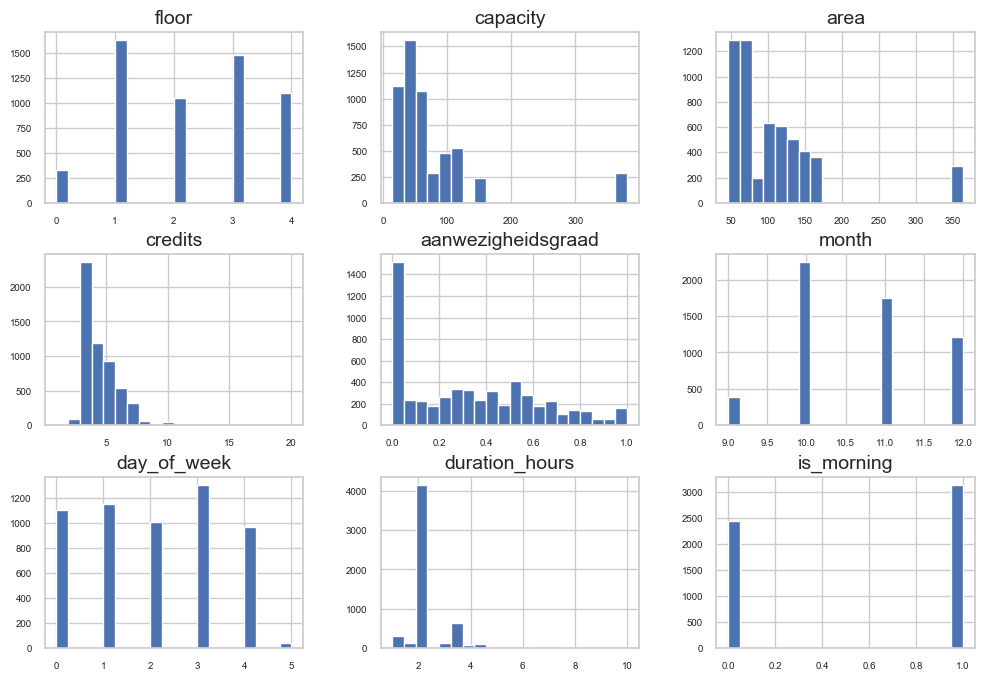

In [475]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)

df.hist(bins=20, figsize=(12, 8))
plt.show()

array([[<Axes: xlabel='day_of_week', ylabel='day_of_week'>,
        <Axes: xlabel='month', ylabel='day_of_week'>,
        <Axes: xlabel='duration_hours', ylabel='day_of_week'>,
        <Axes: xlabel='capacity', ylabel='day_of_week'>,
        <Axes: xlabel='area', ylabel='day_of_week'>,
        <Axes: xlabel='credits', ylabel='day_of_week'>,
        <Axes: xlabel='aanwezigheidsgraad', ylabel='day_of_week'>],
       [<Axes: xlabel='day_of_week', ylabel='month'>,
        <Axes: xlabel='month', ylabel='month'>,
        <Axes: xlabel='duration_hours', ylabel='month'>,
        <Axes: xlabel='capacity', ylabel='month'>,
        <Axes: xlabel='area', ylabel='month'>,
        <Axes: xlabel='credits', ylabel='month'>,
        <Axes: xlabel='aanwezigheidsgraad', ylabel='month'>],
       [<Axes: xlabel='day_of_week', ylabel='duration_hours'>,
        <Axes: xlabel='month', ylabel='duration_hours'>,
        <Axes: xlabel='duration_hours', ylabel='duration_hours'>,
        <Axes: xlabel='capacity', 

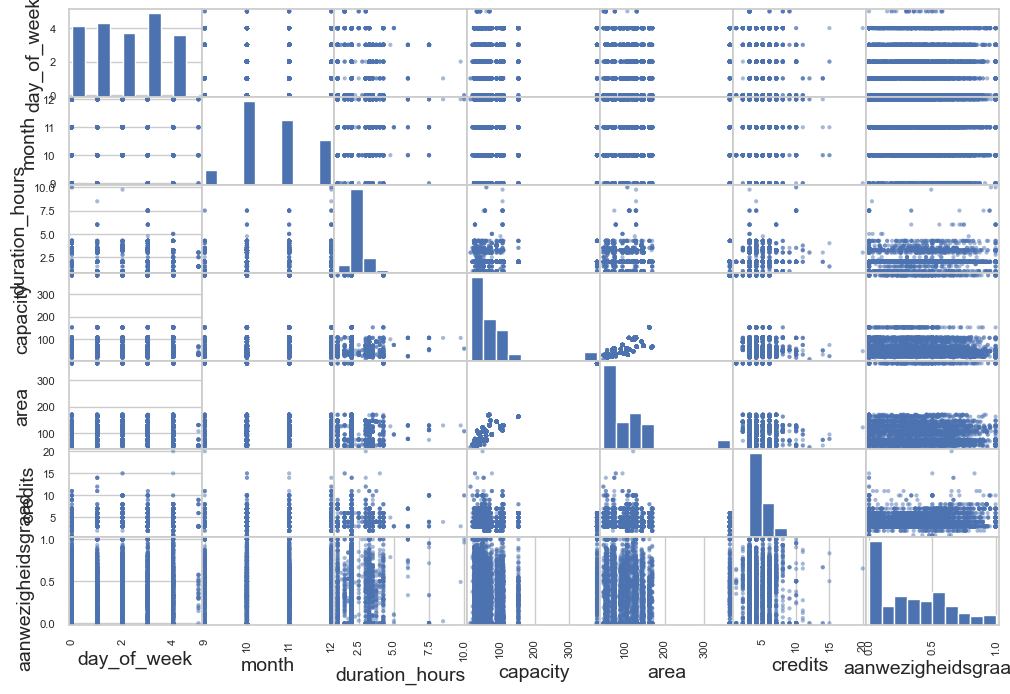

In [476]:
from pandas.plotting import scatter_matrix

attributes = [ "day_of_week","month","duration_hours",
              "capacity","area","credits","aanwezigheidsgraad"]
scatter_matrix(df[attributes], figsize=(12, 8))

we can see that there is a kind of correlation between area & capacity. Nice to see that physics is well respected in this dataset.

Text(0.5, 0, 'aanwezigheidsgraad')

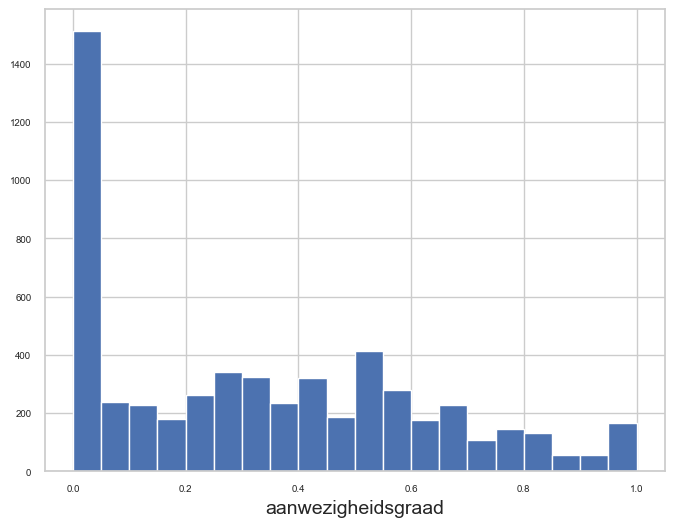

In [477]:
df['aanwezigheidsgraad'].hist(bins=20, figsize=(8, 6))
plt.xlabel('aanwezigheidsgraad')

In [478]:
df['aanwezigheidsgraad'].describe()

count    5581.000000
mean        0.330350
std         0.287466
min         0.000000
25%         0.028571
50%         0.307692
75%         0.538462
max         1.000000
Name: aanwezigheidsgraad, dtype: float64

Our aanwezigheidsgraad is right skewed. It means most of the lesson have few people attending it.

Would it be possible that is due to error in the way we collected the data ?

Text(0, 0.5, 'aanwezigheidsgraad')

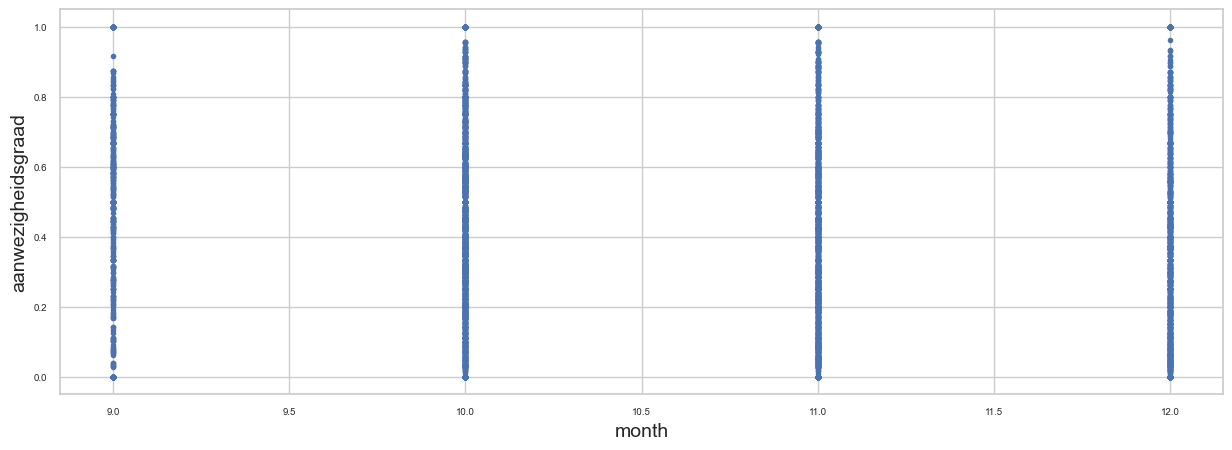

In [479]:
plt.subplots(figsize=(15,5))
plt.plot(df['month'],df['aanwezigheidsgraad'],'b.')
plt.xlabel("month")
plt.ylabel("aanwezigheidsgraad")

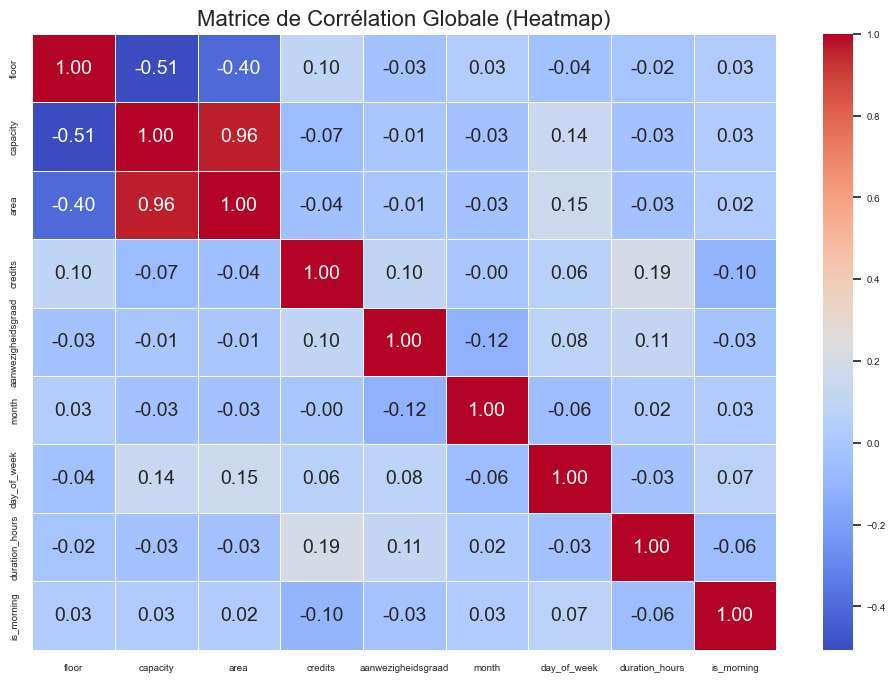

In [480]:
# 1. Sécurité : On ne garde QUE les colonnes numériques (sinon le calcul plante sur du texte)
colonnes_numeriques = df.select_dtypes(include=['int64', 'float64', 'int32'])

# 2. Calcul de la matrice de corrélation
matrice_corr = colonnes_numeriques.corr()

# 3. Configuration et affichage du graphique (Heatmap)
plt.figure(figsize=(12, 8)) # On met une bonne taille pour que ce soit lisible

# Paramètres :
# annot=True : Affiche les chiffres dans les cases
# cmap='coolwarm' : Met du bleu pour le négatif et du rouge pour le positif
# fmt=".2f" : Arrondit à 2 chiffres après la virgule
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation Globale (Heatmap)", fontsize=16)
plt.show()

In [481]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["aanwezigheidsgraad"].sort_values(ascending=False)

aanwezigheidsgraad    1.000000
duration_hours        0.113143
credits               0.104899
day_of_week           0.077158
area                 -0.007948
capacity             -0.010153
is_morning           -0.026663
floor                -0.033701
month                -0.118035
Name: aanwezigheidsgraad, dtype: float64

The feature month has big correlation with the aanwezigheidgraad.

WHAT OTHER PLOT & FEATURE ENGINEERING COULD WE PERFORM ?

Interesting things to see here :

inverse correlation between aanwezigheidgraad and date :)

we should do better feature engineering on those

### What could have an impact other than what we have in this data ?

it's quite important to have some distance with our analysis. Our analysis could be "good" in our own context with this data. But it's still a "lab". The real world has too many possible variable that have an impact.

Imagine there is a strike as we experienced a lot of strike in Belgium with the last Arizona coaltion. THE NMBS/SNCB having a lot of delay etc could be a reason why student are reluctant to go the course.
Let's say we have a group of student blocking the lesson because of some political reason ?
Are we sure we could get this through our analysis ? Of course not.

we could a million possibilities having an impact.

# 4. Prepare the Data for Machine Learning Algorithms

In [482]:


#go back from the original data to start with our train and test sets and all transformations and feature engineering, 
# to prepare for model training and evaluation


# # drop labels for training set my 'X's
X_train = train_set.drop("aanwezigheidsgraad", axis=1)

# #keep the target 'Y'
y_train = train_set["aanwezigheidsgraad"].copy()

# same for the test set that we will use at the end to evaluate perf
X_test = test_set.drop("aanwezigheidsgraad", axis=1)
y_test = test_set["aanwezigheidsgraad"].copy()

In [483]:
X_train.head(10)

,﻿date,from,until,activity,subgroup,program,floor,roomcategory,capacity,area,credits
17410,20251028,91500,123000,Activerend hoorcollege,PBA-BM-SCM/VT/KM,PBA-BM-SCM,2,auditorium,101,125.08,4
16061,20251027,180000,200000,Activerend hoorcollege,PGD-SAL/1,PGD-SAL,1,leslokaal,26,58.05,6
1010,20251202,103000,123000,Oefensessie,PBA-VG-VG/2F1,PBA-VG-VG,1,leslokaal,26,58.05,3
3795,20251002,133000,153000,Activerend hoorcollege,PBA-TIN-TI/2A2,PBA-TIN-TI,4,laptoplokaal,42,88.68,5
931,20251112,81500,101500,Activerend hoorcollege,PBA-VG-VG/2F1,PBA-VG-VG,1,auditorium,153,161.88,3
2010,20251114,103000,123000,Activerend hoorcollege,PBA-TIN-TI/2C1,PBA-TIN-TI,4,practicum,72,146.63,4
691,20251016,81500,101500,Practicum,PBA-EM/1C2,PBA-EM,1,laboratorium,25,68.50,3
533,20251024,103000,123000,Activerend hoorcollege,PBA-EM-KL/2B,PBA-EM-KL,3,leslokaal,44,71.06,6
3444,20251119,133000,153000,Oefensessie,PBA-VG-LAM/1B1,PBA-VG-LAM,4,leslokaal,50,70.08,4
15975,20251211,133000,143000,Activerend hoorcollege,PBA-MET/2C,PBA-MET,2,laptoplokaal,24,56.02,9


Let's perform again our data cleaning and our feature engineering done in the previous section when we were "exploring" the datas.

We will then automate our steps with the help of sci kit learn.

In [484]:
# method to simplify the activity column with fewer categories
def groepeer_activiteit(activiteit):
    activiteit_min = activiteit.lower()
    if 'examen' in activiteit_min:
        return 'Examen'
    elif activiteit == 'Activerend hoorcollege':
        return 'Activerend hoorcollege'
    elif activiteit == 'Oefensessie':
        return 'Oefensessie'
    elif activiteit == 'Practicum':
        return 'Practicum'
    else:
        return 'Andere'


def DataFrameTransformation(df):
    df = df.copy()

    # nettoyage des noms de colonnes (BOM + espaces)
    df.columns = df.columns.str.replace('\ufeff', '').str.strip()

    # ── date → month + day_of_week ──
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek  # 0=lundi, 6=dimanche
    df = df.drop("date", axis=1)

    # ── normalisation from/until (supprimer les secondes) ──
    df['until'] = np.where(df['until'] > 9999, df['until'] // 100, df['until'])
    df['from']  = np.where(df['from']  > 9999, df['from']  // 100, df['from'])

    # ── durée en heures décimales ──
    from_decimal  = (df['from']  // 100) + ((df['from']  % 100) / 60)
    until_decimal = (df['until'] // 100) + ((df['until'] % 100) / 60)
    df['duration_hours'] = until_decimal - from_decimal

    # ── heure de début + indicateur matin ──
    df['start_hour'] = df['from'] // 100
    df['is_morning'] = (df['from'] < 1200).astype(int)

    df = df.drop(['from', 'until'], axis=1)

    # ── regroupement des types d'activités ──
    df['activity'] = df['activity'].apply(groepeer_activiteit)

    # ── suppression des colonnes inutiles ──
    df = df.drop("subgroup", axis=1)

    # regroupement du programme : garder seulement TYPE-DOMAINE
    # ex: "PBA-BM-MK" → "PBA-BM", "PBA-TIN-TI" → "PBA-TIN"
    df['program'] = df['program'].str.split('-').str[:2].str.join('-')

    return df


# to check which columns we have after the transformations and to make sure there are no errors 
# before integrating this function into the pipeline
df_check = DataFrameTransformation(X_train)
print("Colonnes restantes :", df_check.columns.tolist())
print("Shape :", df_check.shape)
df_check.head(3)

Colonnes restantes : ['activity', 'program', 'floor', 'roomcategory', 'capacity', 'area', 'credits', 'month', 'day_of_week', 'duration_hours', 'start_hour', 'is_morning']
Shape : (5581, 12)


,activity,program,floor,roomcategory,capacity,area,credits,month,day_of_week,duration_hours,start_hour,is_morning
17410,Activerend hoorcollege,PBA-BM,2,auditorium,101,125.08,4,10,1,3.25,9,1
16061,Activerend hoorcollege,PGD-SAL,1,leslokaal,26,58.05,6,10,0,2.00,18,0
1010,Oefensessie,PBA-VG,1,leslokaal,26,58.05,3,12,1,2.00,10,1


In [485]:
df_check.head(3)



,activity,program,floor,roomcategory,capacity,area,credits,month,day_of_week,duration_hours,start_hour,is_morning
17410,Activerend hoorcollege,PBA-BM,2,auditorium,101,125.08,4,10,1,3.25,9,1
16061,Activerend hoorcollege,PGD-SAL,1,leslokaal,26,58.05,6,10,0,2.00,18,0
1010,Oefensessie,PBA-VG,1,leslokaal,26,58.05,3,12,1,2.00,10,1


Let's write our pipeline !

In [486]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LinearRegression

# all the numerical features after feat engineering will be scaled !
num_features = [
    'month', 'day_of_week', 'duration_hours',
    'start_hour', 'is_morning',
    'capacity', 'area', 'credits', 'floor'
]

#all the categorical features after feat engineering will be one-hot encoded !
cat_features = ['activity', 'program', 'roomcategory']

num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# All pipeline : feat eng and preprocessing and our first model 
full_pipeline = Pipeline([
    ('feature_eng',   FunctionTransformer(DataFrameTransformation, validate=False)),
    ('preprocessing', preprocessing),
    ('model',         LinearRegression())
])



# 5. Select and Train a Model

### Let's first remember what was our target  (Y) info : 

count    6977.000000

mean        0.328417

std         0.287025

min         0.000000

25%         0.026316

50%         0.306122

75%         0.533333

max         1.000000

Name: aanwezigheidsgraad, dtype: float64

In [487]:
from sklearn.model_selection import cross_val_score


# RMSE en cross-validation ✅
rmse_scores = -cross_val_score(
    full_pipeline, X_train, y_train,
    scoring='neg_root_mean_squared_error', cv=5
)

# MAE aussi en cross-validation ✅ (même logique)
mae_scores = -cross_val_score(
    full_pipeline, X_train, y_train,
    scoring='neg_mean_absolute_error', cv=5
)

print("=== LinearRegression ===")
print(f"RMSE moyen : {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")
print(f"MAE moyen  : {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")

=== LinearRegression ===
RMSE moyen : 0.2642 (+/- 0.0023)
MAE moyen  : 0.2175 (+/- 0.0036)


In [488]:
from sklearn.ensemble import RandomForestRegressor

# nouveau pipeline avec RandomForest
forest_pipeline = Pipeline([
    ('feature_eng',   FunctionTransformer(DataFrameTransformation, validate=False)),
    ('preprocessing', preprocessing),
    ('model',         RandomForestRegressor(n_estimators=100, random_state=42))
])

rmse_forest = -cross_val_score(
    forest_pipeline, X_train, y_train,
    scoring='neg_root_mean_squared_error', cv=5
)
mae_forest = -cross_val_score(
    forest_pipeline, X_train, y_train,
    scoring='neg_mean_absolute_error', cv=5
)

print("=== RandomForestRegressor ===")
print(f"RMSE moyen : {rmse_forest.mean():.4f} (+/- {rmse_forest.std():.4f})")
print(f"MAE moyen  : {mae_forest.mean():.4f} (+/- {mae_forest.std():.4f})")

=== RandomForestRegressor ===
RMSE moyen : 0.2328 (+/- 0.0054)
MAE moyen  : 0.1708 (+/- 0.0028)


Random Forest have a really better error. Error is lesser than linear regression. This is easy to understand, we saw that our data are NOT linear during the part 3.

We can obviously make it better with fine tuning the hyperparameter .. But instead let's first try other models !

In [489]:
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

# ── SVR (Support Vector Regression) ──
svr_pipeline = Pipeline([
    ('feature_eng',   FunctionTransformer(DataFrameTransformation, validate=False)),
    ('preprocessing', preprocessing),
    ('model',         SVR())
])

rmse_svr = -cross_val_score(svr_pipeline, X_train, y_train,
                             scoring='neg_root_mean_squared_error', cv=5)
mae_svr  = -cross_val_score(svr_pipeline, X_train, y_train,
                             scoring='neg_mean_absolute_error', cv=5)

print("=== SVR ===")
print(f"RMSE moyen : {rmse_svr.mean():.4f} (+/- {rmse_svr.std():.4f})")
print(f"MAE moyen  : {mae_svr.mean():.4f} (+/- {mae_svr.std():.4f})")

=== SVR ===
RMSE moyen : 0.2349 (+/- 0.0037)
MAE moyen  : 0.1797 (+/- 0.0014)


In [490]:
# Gradient Boosting Regressor
gb_pipeline = Pipeline([
    ('feature_eng',   FunctionTransformer(DataFrameTransformation, validate=False)),
    ('preprocessing', preprocessing),
    ('model',         GradientBoostingRegressor(random_state=42))
])

rmse_gb = -cross_val_score(gb_pipeline, X_train, y_train,
                            scoring='neg_root_mean_squared_error', cv=5)
mae_gb  = -cross_val_score(gb_pipeline, X_train, y_train,
                            scoring='neg_mean_absolute_error', cv=5)

print("=== GradientBoosting ===")
print(f"RMSE moyen : {rmse_gb.mean():.4f} (+/- {rmse_gb.std():.4f})")
print(f"MAE moyen  : {mae_gb.mean():.4f} (+/- {mae_gb.std():.4f})")

=== GradientBoosting ===
RMSE moyen : 0.2495 (+/- 0.0032)
MAE moyen  : 0.2065 (+/- 0.0023)


In [491]:
from sklearn.neighbors import KNeighborsRegressor

knn_pipeline = Pipeline([
    ('feature_eng',   FunctionTransformer(DataFrameTransformation, validate=False)),
    ('preprocessing', preprocessing),
    ('model',         KNeighborsRegressor())
])

rmse_knn = -cross_val_score(knn_pipeline, X_train, y_train,
                             scoring='neg_root_mean_squared_error', cv=5)
mae_knn  = -cross_val_score(knn_pipeline, X_train, y_train,
                             scoring='neg_mean_absolute_error', cv=5)

print("=== KNeighborsRegressor ===")
print(f"RMSE moyen : {rmse_knn.mean():.4f} (+/- {rmse_knn.std():.4f})")
print(f"MAE moyen  : {mae_knn.mean():.4f} (+/- {mae_knn.std():.4f})")

=== KNeighborsRegressor ===
RMSE moyen : 0.2434 (+/- 0.0064)
MAE moyen  : 0.1837 (+/- 0.0018)


let's put the results of all our model to compare them : 

In [492]:
print("=== LinearRegression ===")
print(f"RMSE moyen : {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")
print(f"MAE moyen  : {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")

print("=== RandomForestRegressor ===")
print(f"RMSE moyen : {rmse_forest.mean():.4f} (+/- {rmse_forest.std():.4f})")
print(f"MAE moyen  : {mae_forest.mean():.4f} (+/- {mae_forest.std():.4f})")

print("=== SVR ===")
print(f"RMSE moyen : {rmse_svr.mean():.4f} (+/- {rmse_svr.std():.4f})")
print(f"MAE moyen  : {mae_svr.mean():.4f} (+/- {mae_svr.std():.4f})")

print("=== GradientBoosting ===")
print(f"RMSE moyen : {rmse_gb.mean():.4f} (+/- {rmse_gb.std():.4f})")
print(f"MAE moyen  : {mae_gb.mean():.4f} (+/- {mae_gb.std():.4f})")

print("=== KNeighborsRegressor ===")
print(f"RMSE moyen : {rmse_knn.mean():.4f} (+/- {rmse_knn.std():.4f})")
print(f"MAE moyen  : {mae_knn.mean():.4f} (+/- {mae_knn.std():.4f})")

=== LinearRegression ===
RMSE moyen : 0.2642 (+/- 0.0023)
MAE moyen  : 0.2175 (+/- 0.0036)
=== RandomForestRegressor ===
RMSE moyen : 0.2328 (+/- 0.0054)
MAE moyen  : 0.1708 (+/- 0.0028)
=== SVR ===
RMSE moyen : 0.2349 (+/- 0.0037)
MAE moyen  : 0.1797 (+/- 0.0014)
=== GradientBoosting ===
RMSE moyen : 0.2495 (+/- 0.0032)
MAE moyen  : 0.2065 (+/- 0.0023)
=== KNeighborsRegressor ===
RMSE moyen : 0.2434 (+/- 0.0064)
MAE moyen  : 0.1837 (+/- 0.0018)


Our performer is the RandomForestRegressor ..

# 6. Fine-Tune Your Model

Let's fine tune our Random Forest Regressor !

In [493]:
from sklearn.model_selection import GridSearchCV

# ── GridSearch sur RandomForest ──
forest_pipeline_gs = Pipeline([
    ('feature_eng',   FunctionTransformer(DataFrameTransformation, validate=False)),
    ('preprocessing', preprocessing),
    ('model',         RandomForestRegressor(random_state=42))
])

param_grid = [
    {
        'model__n_estimators': [50, 100, 200],
        'model__max_features': [4, 6, 8]
    }
]

grid_search = GridSearchCV(
    forest_pipeline_gs, param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur RMSE (CV)   : {-grid_search.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Meilleurs paramètres : {'model__max_features': 6, 'model__n_estimators': 200}
Meilleur RMSE (CV)   : 0.2360


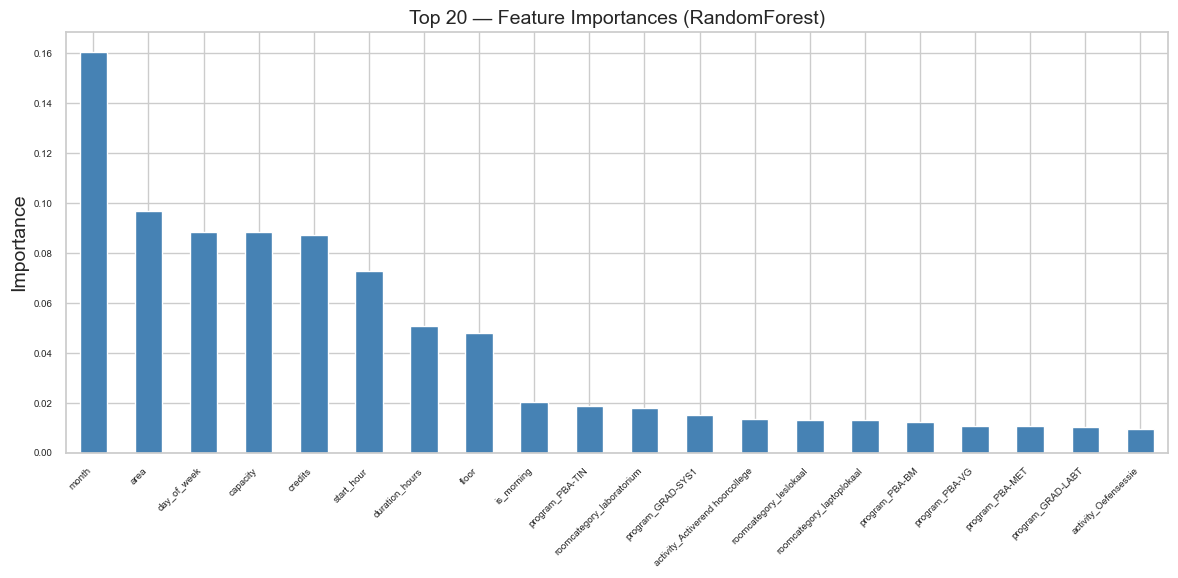


Top 10 features les plus importantes :
month              0.160363
area               0.096914
day_of_week        0.088399
capacity           0.088269
credits            0.087174
start_hour         0.073032
duration_hours     0.050725
floor              0.048037
is_morning         0.020455
program_PBA-TIN    0.018759


In [494]:
# ── Feature Importances ──
# récupérer le modèle final depuis le grid search
best_model = grid_search.best_estimator_

# récupérer les noms des features après OneHotEncoding
ohe_features = (best_model.named_steps['preprocessing']
                .named_transformers_['cat']
                .named_steps['onehotencoder']
                .get_feature_names_out(cat_features).tolist())

feature_names = num_features + ohe_features

# récupérer les importances
importances = best_model.named_steps['model'].feature_importances_

# trier et visualiser
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 — Feature Importances (RandomForest)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 features les plus importantes :")
print(feat_imp.head(10).to_string())

# 7. Launch, monitor, and maintain your system.

In [495]:
import joblib
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# ── évaluation FINALE sur le test set (une seule fois) ──
final_model = grid_search.best_estimator_

y_pred_test = final_model.predict(X_test)

rmse_final = root_mean_squared_error(y_test, y_pred_test)
mae_final  = mean_absolute_error(y_test, y_pred_test)

print("=== Évaluation finale sur le TEST SET ===")
print(f"RMSE : {rmse_final:.4f}")
print(f"MAE  : {mae_final:.4f}")

# ── sauvegarde du modèle ──

final_model = joblib.load('model.pkl')
print("\n✓ Modèle sauvegardé dans model.pkl")

# ── vérification du rechargement ──
model_reloaded = joblib.load('model.pkl')
test_pred = model_reloaded.predict(X_test.head(3))
print(f"\nTest rechargement : {test_pred}")

=== Évaluation finale sur le TEST SET ===
RMSE : 0.2350
MAE  : 0.1695

✓ Modèle sauvegardé dans model.pkl

Test rechargement : [0.38080655 0.10568463 0.28887387]
